In [1]:
import sys
from flow import flow_dataclasses, regulator
from flow import create
from flow.models.grids import *

print("sys._is_gil_enabled() =", sys._is_gil_enabled())

n_f=2
approximation = "NLO"
dim=2

path_save = 'checks/kpz_1grid_2D_NLO'

alpha = 2
beta = 1
coeff_nu = 1
r  = lambda x : regulator.wett_alpha_beta(x, alpha, beta)
r_ = lambda x : regulator.wett_alpha_beta_(x, alpha, beta)

N_p, p_min, p_max = 100, 0.01, 100
N_w, w_min, w_max = 100, 0.01, 100
q_max, deg_q, degtheta = 4, 40, 10

params_grid_external=flow_dataclasses.Params_grid_external(N_p=N_p, p_min=p_min, p_max=p_max,
                                                           N_w=N_w, w_min=w_min, w_max=w_max)
params_grid_internal=flow_dataclasses.Params_grid_internal(deg_q, q_max, degtheta)

model_params = n_f, approximation, dim, params_grid_external, params_grid_internal, r, r_, coeff_nu

g_in = 31.
etas_in = np.array([0., 0.])
shape_f = (n_f, N_p, N_w)
f_in = np.ones(shape_f)

ds = 0.002

IC = flow_dataclasses.IC_NLO(g_in=g_in, etas_in=etas_in, fs_in=f_in)

evo_params = IC, ds, path_save

sys._is_gil_enabled() = True


In [2]:
flow = create.create('KPZ', model_params,'evo1', evo_params)
s_fin=-120*ds*4-ds
n_print=120
n_save_params=120
n_save_f=120

=== Model is has the following parameters: ===
n_f=2
approximation=NLO
dim=2
Integral_pfixed=<bound method ModelKPZ.Integral_pfixed_dD_NLO of <flow.models.model_kpz.ModelKPZ object at 0x7fbd70350050>>
f_rhs_logder_calc=<bound method ModelKPZ.f_rhs_logder_calc_NLO of <flow.models.model_kpz.ModelKPZ object at 0x7fbd70350050>>
p_min=0.01
p_max=100
Np=100
grid_scale=log
p=ndarray(shape=(100,): 0.0, 0.01, ..., 100.0)
Nw=100
w=ndarray(shape=(100,): 0.0, 0.01, ..., 100.0)
w_min=0.01
w_max=100
external_grid_shape=(100, 100)
q_max=4
degq=40
q=ndarray(shape=(40,): 0.0035245805788817197, 0.018547522601086053, ..., 3.9964754194211185)
wq=ndarray(shape=(40,): 0.009042554197072698, 0.020996569062307627, ..., 0.009042554197072698)
vdim=0.15915494309189535
Jdim=ndarray(shape=(40,): 0.0005609544214547197, 0.0029519299040714933, ..., 0.6360588179461267)
theta_max=3.141592653589793
degtheta=10
theta=ndarray(shape=(10,): 0.040987529158554005, 0.21195796795501298, ..., 3.100605124431239)
wtheta=ndarray(sha

In [3]:
flow.rg_evolution(s_fin, n_print, n_save_params, n_save_f)

START rg_evolution
s 		|		 eta's 		|	  g 	|	 -I's[0,0]
	0.000 | 	2.39891	0.56539 | 	31.044 | 	1.23345	0.00001
	-0.240 | 	1.67317	0.46162 | 	34.652 | 	1.67545	0.46270
	-0.480 | 	1.36538	0.41548 | 	36.287 | 	1.36648	0.41601
	-0.720 | 	1.21118	0.39135 | 	36.928 | 	1.21176	0.39163
	-0.960 | 	1.12731	0.37686 | 	37.056 | 	1.12762	0.37701
FINISH Saved in checks/kpz_1grid_2D_NLO


In [ ]:
#compare to flowNLO:  -0.960	1.12731	0.37686	37.056	1.12762	0.37701 OK

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from flow.file_utils import read_par_bin

from importlib import reload
from flow import flow_dataclasses
reload(flow_dataclasses)
from flow import flow_dataclasses

import my_plot_NLO
reload(my_plot_NLO)
import my_plot_NLO

In [9]:
p = grid_log0(p_min, p_max, N_p)
w = grid_log0(w_min, w_max, N_w)
f = read_par_bin(path_save,'f.bin',shape_f)

file = f.bin shape = (2, 100, 100)
n_steps = 5


In [10]:
f.shape

(5, 2, 100, 100)

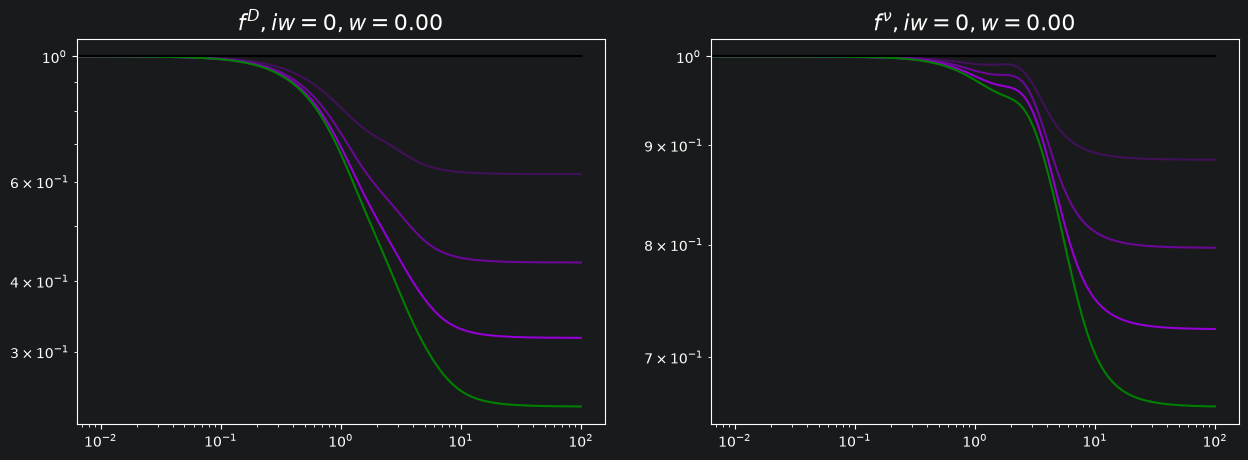

In [11]:
stepmax = f.shape[0]

my_plot_NLO.fs_of_p_w0_fixed_alphas(f[:,0,:,:], f[:,1,:,:], f_in[0], f_in[1], p, w, iw0=0, 
                                    s0=0,stepmax=stepmax,step=1,xscale='log', yscale='log')

In [12]:
shape_par = (1+n_f+1,)
par = read_par_bin(path_save, 'flow_parameters.bin', shape_par)

file = flow_parameters.bin shape = (4,)
n_steps = 5


In [13]:
par.shape

(5, 4)

In [14]:
s = par[:,0]
eta_D = par[:,1]
eta_nu = par[:,2]
g = par[:,3]

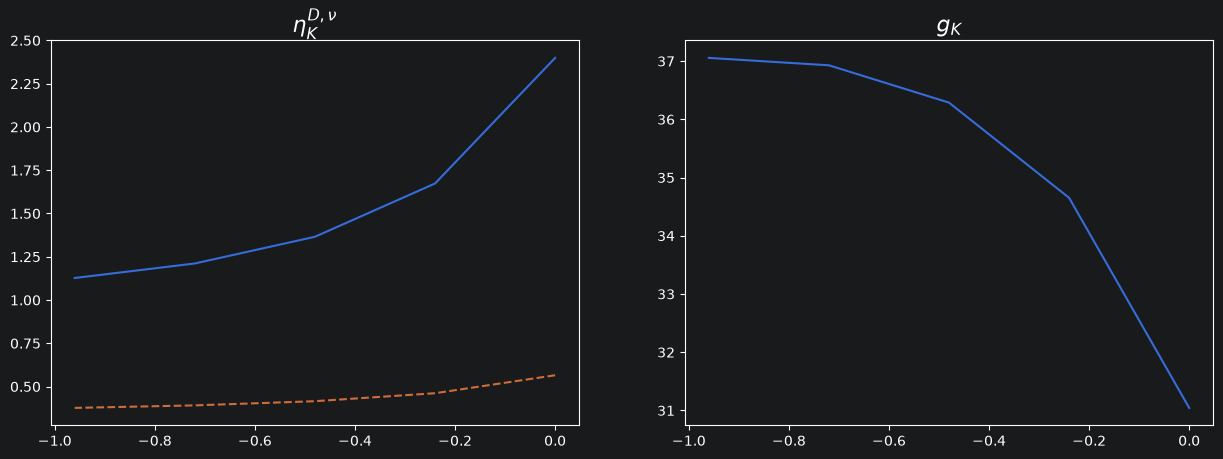

In [15]:
num=2
fig, ax = plt.subplots(1,num, figsize=(7.5*num, 5))

ax[0].set_title(r'$\eta^{D,\nu}_K$', fontsize=16)
ax[0].plot(s, eta_D)
ax[0].plot(s, eta_nu,'--')

ax[1].set_title(r'$g_K$', fontsize=16)
ax[1].plot(s, g)

plt.show()